# Task 1

Loading station  0  out of  200
Loading station  50  out of  200
Loading station  100  out of  200
Loading station  150  out of  200
Loading station  200  out of  200
done


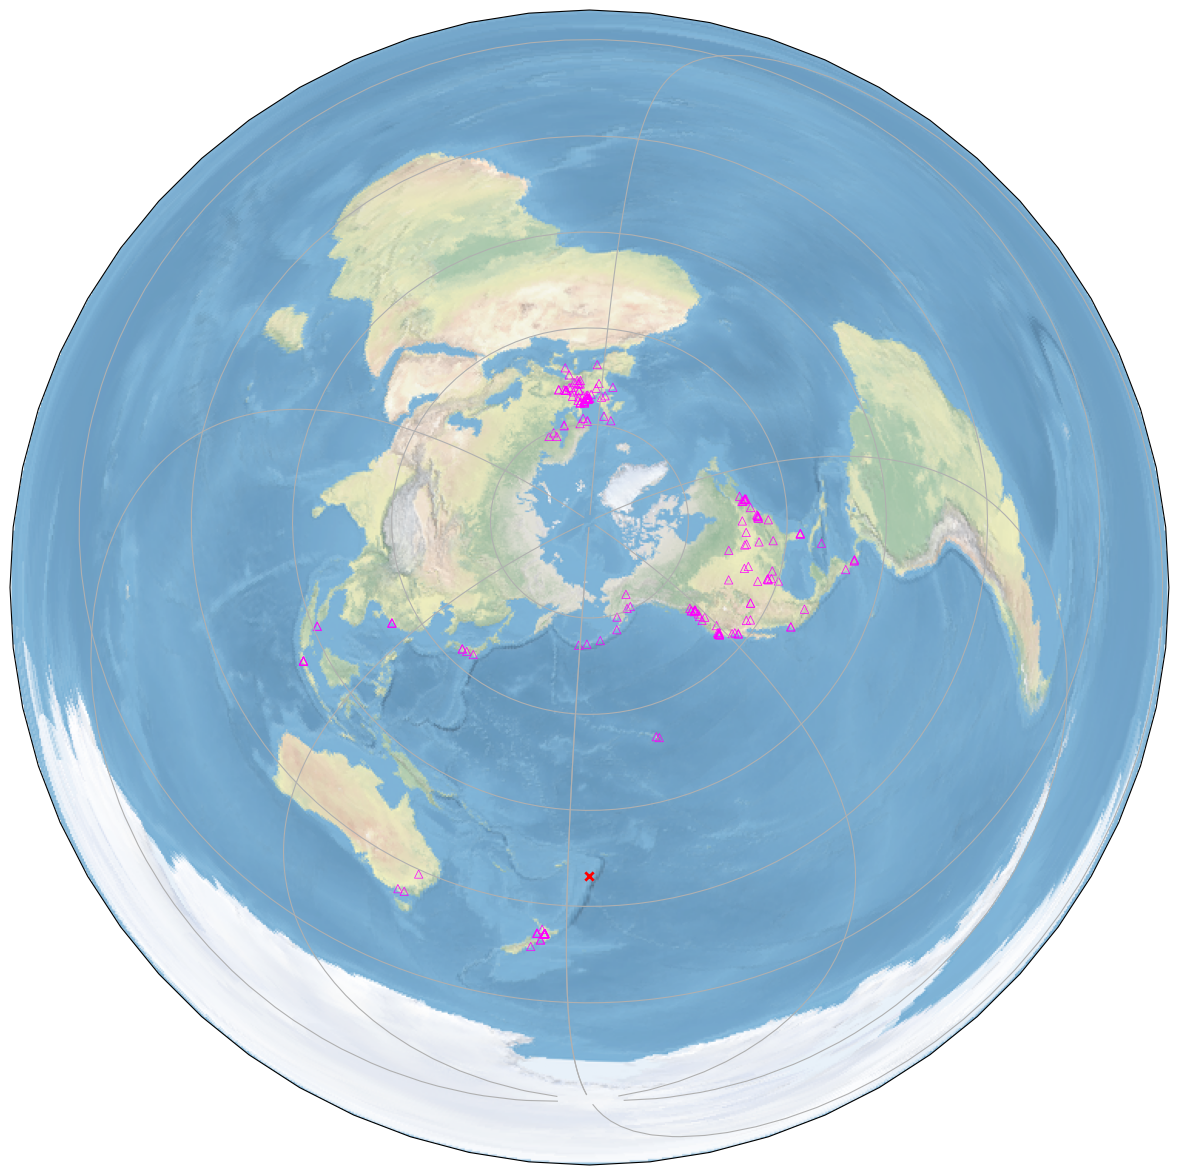

Smallest great cricle distance is 2137.71km. Largest great circle distance is 17687.13km


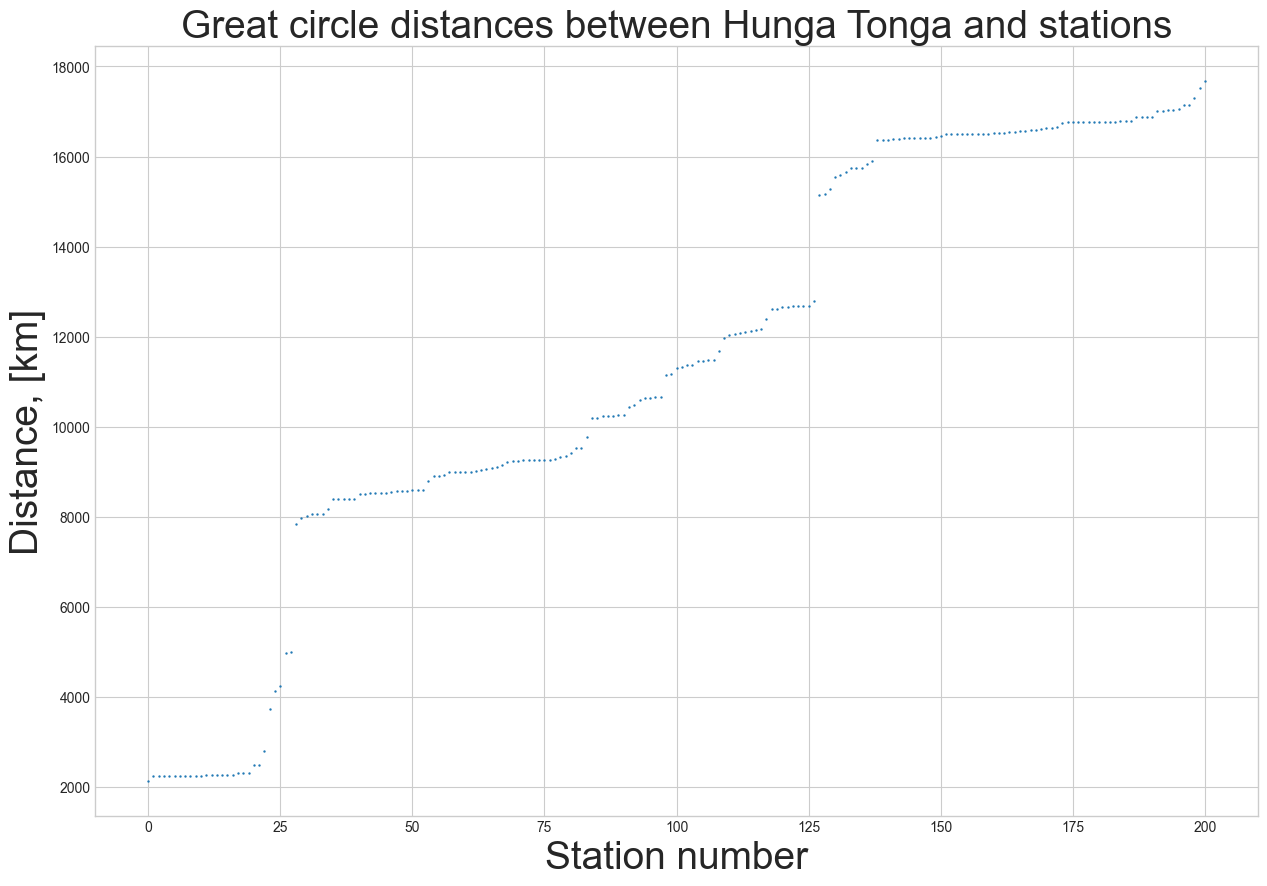

In [1]:
# These code snippets that parse parts of run_provided.m
# have kindly been shared by Markus Bjørklund
#
# Please note that you'll need to do some work to put these snippets 
# into work in the appropriate order, for example, in a Jupyter notebook
# or by calling things in the right order from a main()


#For parsing and general analysis
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

#For datetime objects
from matplotlib import dates
from datetime import datetime, timedelta
import dateutil.parser

#For map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from geopy.distance import great_circle

# Set path for data
path = os.path.abspath('') + '/' #Working directory path (Where program is run from)
fn_list = os.listdir(path + '/data') #List of all file names

def parse(num_files=None):
    #Read files and store contents. Accepts user input for number of files to read.
    if num_files:
        N_files = num_files
    else:
        N_files = len(fn_list)

    # Initialize
    lats = np.zeros(N_files)
    lons = np.zeros(N_files)
    dt = np.zeros(N_files)

    N_samples = 720000 #Size of the datasets in the files. Hard coded unless you want dynamic allocation (lists, slower)
    data_collection = np.zeros((N_files,N_samples)) # all station data
    times_collection = np.zeros((N_files,N_samples), dtype=datetime) # all correponding time vectors


    #Loop over files
    for ii in range(N_files):
        if (ii%50) == 0:
            print('Loading station ' , ii, ' out of ' , N_files-1)

        this_fn = h5py.File(path + 'data/' + fn_list[ii], 'r') # The file path we will read

        # Read the latitude and longitude attributes for the station and put into vectors
        lats[ii] = this_fn.attrs['latitude']
        lons[ii] = this_fn.attrs['longitude']

        #Read tree structure and load dataset into aggregate array
        level1 = list(this_fn.keys()) # /waveforms
        level2 = list(this_fn[level1[0]].keys()) # /waveforms/dataset_name
        dataset = this_fn['/' + level1[0] + '/' + level2[0]] #Reading dataset in subgroup
        data = dataset[:] #Extract numpy array from dataset object

        #If missing data, pad with zeros
        if len(data) < N_samples:
            #data = np.pad(data, (0, N_samples-len(data)), 'constant', constant_values=np.nan)
            data = np.pad(data, (0, N_samples-len(data)), 'constant', constant_values=0)

        data_collection[ii,:] = data #Loading numpy array into aggregate data array

        # Figure out the start time and generate a time vector
        start_time_str = dataset.attrs['starttime']
        start_time = dateutil.parser.isoparse(start_time_str) #Time attribute on ISO-format

        dt[ii] = dataset.attrs['delta']
        deltas = np.linspace(0, dt[ii]*(N_samples-1), N_samples) #A duration which can be added to a datetime object
        times = start_time + deltas*timedelta(seconds = 1)
        times_collection[ii,:] = times #Loading times into aggregate array

    print('done')
    return data_collection, times_collection, lats, lons, dt

def plot_map(lats, lons, tonga_latlon):
    northward_offset = 90 #As in sample program
    central_lat = tonga_latlon[0] + northward_offset
    central_lon = tonga_latlon[1]

    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(1, 1, 1, 
    projection=ccrs.AzimuthalEquidistant(central_latitude = central_lat, central_longitude=central_lon))

    #Stock background (Natural Earth)
    ax.stock_img()

    #Make the map global rather than have it zoom in to the extents of any plotted data
    ax.set_global()
    
    #Make gridlines
    ax.gridlines(crs=ccrs.PlateCarree())

    #Plot stations and Hunga Tonga
    ax.scatter(tonga_latlon[1], tonga_latlon[0], marker = 'x', linewidth = 2, 
    color='red', transform=ccrs.PlateCarree()) #Transform is PlateCarree regardless of projection

    ax.scatter(lons, lats, marker = '^', linewidth = 0.5, facecolor='none', 
    edgecolor='magenta', transform=ccrs.PlateCarree()) #Transform is PlateCarree regardless of projection

    plt.show()


def circle_distance(n_files, lats, lons, tonga_latlon):
    #Calculate great circle distance. Using geopy.great_circle
    dists = []
    for i in range(n_files):
        dists.append(great_circle((tonga_latlon[0], tonga_latlon[1]) , (lats[i], lons[i])).m)
        
    dists = np.array(dists)
    dists_km = dists/1000
    
    print('Smallest great cricle distance is {:.2f}km. Largest great circle distance is {:.2f}km'.format(
        np.min(dists_km), np.max(dists_km)))
    
    plt.style.use('seaborn-v0_8-whitegrid')
    n_vec = np.linspace(0,n_files-1,n_files)
    fig = plt.figure(figsize=(15,10))
    ax = fig.add_subplot(111)
    ax.scatter(n_vec, np.sort(dists_km), s=0.5)
    ax.set_xlabel('Station number', fontsize=28)
    ax.set_ylabel('Distance, [km]', fontsize=28)
    ax.set_title('Great circle distances between Hunga Tonga and stations', fontsize=28)
    plt.show()

    return dists_km


# READ DATA
data_collection, times_collection, lats, lons, dt = parse()
n_files = len(lats)

# Hunga Tonga location
tonga_latlon = [-20.550, -175.385] # latitude and longitude

# Map
plot_map(lats, lons, tonga_latlon)

dists_km = circle_distance(n_files, lats, lons, tonga_latlon)